# 2. Segmentación de clientes con K-Means — RetailMax

**Objetivo.** Descubrir segmentos accionables usando edad, ingreso anual y puntuación de gasto. K-Means es no supervisado: no existe una etiqueta correcta previa; la calidad se evalúa mediante cohesión/separación y utilidad comercial.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42
df = pd.read_csv(Path('data/retailmax.csv'), dtype={'CustomerID': str})
feature_columns = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0001,Male,19,15,39
1,0002,Male,21,15,81
2,0003,Female,20,16,6
3,0004,Female,23,16,77
4,0005,Female,31,17,40


## Selección de features

Se utilizan edad, ingreso anual y puntuación de gasto porque describen etapa de vida, poder adquisitivo y comportamiento de compra. `CustomerID` no contiene comportamiento y `Gender` es categórica; se deja fuera de la distancia inicial, aunque se recuperará al perfilar los resultados.

In [2]:
features = df[feature_columns]
features.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


## Conservación de índices

Seleccionar columnas no reinicia los índices. Por ello, cada fila de `features` sigue correspondiendo al mismo cliente de `df`, lo que permite agregar las etiquetas de cluster sin perder alineación.

In [3]:
display(df.sample(5, random_state=42))
display(features.sample(5, random_state=42))
assert df.index.equals(features.index)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
95,0096,Male,24,60,52
15,0016,Male,22,20,79
30,0031,Male,60,30,4
158,0159,Male,34,78,1
128,0129,Male,59,71,11


,Age,Annual Income (k$),Spending Score (1-100)
95,24,60,52
15,22,20,79
30,60,30,4
158,34,78,1
128,59,71,11


## Estandarización

K-Means usa distancias euclidianas. `StandardScaler` transforma cada feature para que tenga media 0 y desviación estándar poblacional 1, evitando que una escala numérica domine a las demás.

In [4]:
assert features.notna().all().all(), 'Existen valores faltantes en las variables del modelo.'
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

print(type(scaled_features))
print('Dimensiones:', scaled_features.shape)
display(scaled_features[0:3])
display(pd.DataFrame(scaled_features, columns=feature_columns).agg(['mean', 'std']).round(3))

<class 'numpy.ndarray'>
Dimensiones: (200, 3)


array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298]])

,Age,Annual Income (k$),Spending Score (1-100)
mean,-0.000,-0.000,-0.000
std,1.003,1.003,1.003


## Creación inicial de 3 clusters

Siguiendo la implementación indicada en la actividad, primero se ajusta K-Means con `k=3`, inicialización `k-means++`, un máximo de 300 iteraciones y 10 inicializaciones. `fit_predict` entrena el modelo y devuelve una etiqueta para cada uno de los 200 clientes.

Número de etiquetas: 200


,Clientes
Cluster_k3,
0,68
1,41
2,91


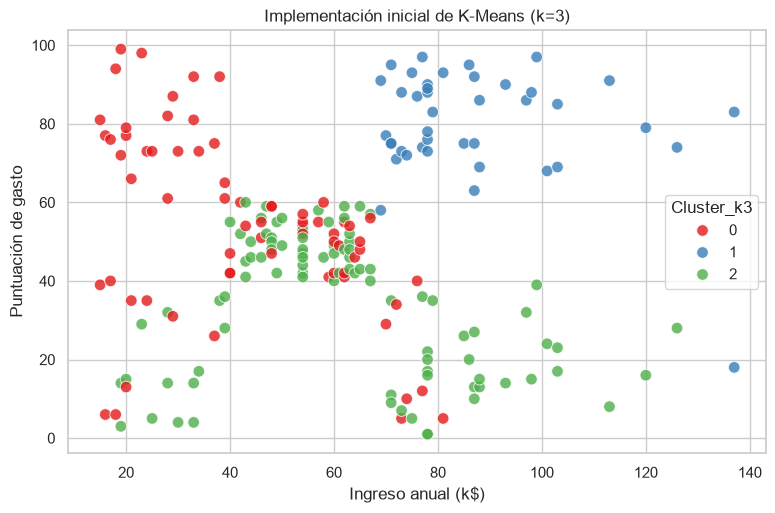

In [5]:
kmeans_3 = KMeans(n_clusters=3, init='k-means++', max_iter=300,
                  n_init=10, random_state=42)
clusters_3 = kmeans_3.fit_predict(scaled_features)
df['Cluster_k3'] = clusters_3

print('Número de etiquetas:', len(clusters_3))
display(df['Cluster_k3'].value_counts().sort_index().rename('Clientes').to_frame())

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Cluster_k3', palette='Set1', s=70, alpha=.8, ax=ax)
ax.set(title='Implementación inicial de K-Means (k=3)', xlabel='Ingreso anual (k$)',
       ylabel='Puntuación de gasto')
plt.show()

## Evaluación adicional del número de clusters

Se comparan valores de `k=2` a `k=10` con dos criterios complementarios:

- **Inercia:** suma de distancias cuadráticas dentro de los clusters; buscamos un “codo”. Siempre disminuye al aumentar `k`.
- **Silhouette:** combina cohesión y separación; valores mayores son mejores.

,k,inercia,silhouette
0,2,389.386,0.335
1,3,295.212,0.358
2,4,205.225,0.404
3,5,168.248,0.417
4,6,133.868,0.427
5,7,117.012,0.417
6,8,103.829,0.409
7,9,92.349,0.420
8,10,81.987,0.397


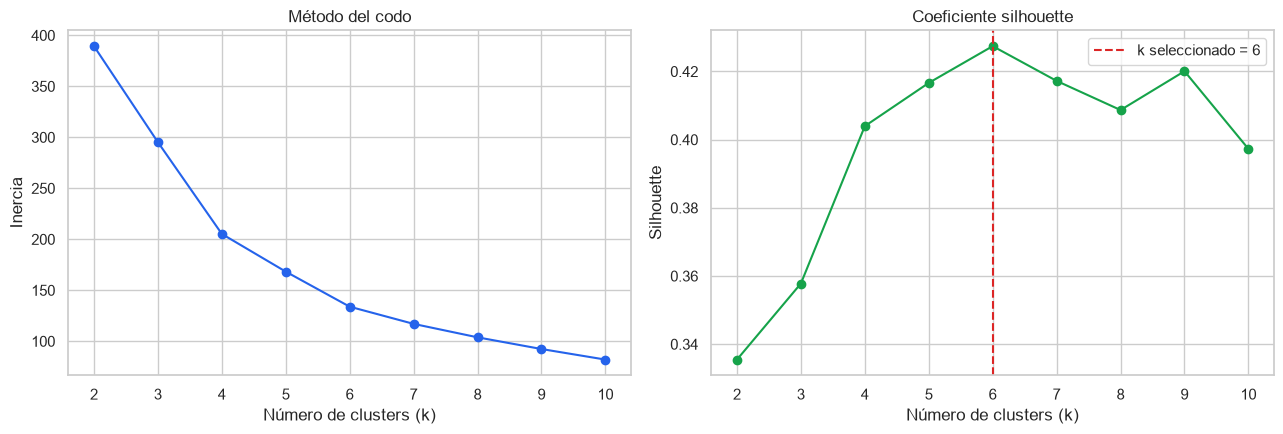

In [6]:
ks = range(2, 11)
inertias, silhouettes = [], []

for k in ks:
    candidate = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = candidate.fit_predict(scaled_features)
    inertias.append(candidate.inertia_)
    silhouettes.append(silhouette_score(scaled_features, labels))

selection = pd.DataFrame({'k': list(ks), 'inercia': inertias, 'silhouette': silhouettes})
display(selection.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(selection['k'], selection['inercia'], marker='o', color='#2563EB')
axes[0].set(title='Método del codo', xlabel='Número de clusters (k)', ylabel='Inercia')
axes[1].plot(selection['k'], selection['silhouette'], marker='o', color='#16A34A')
axes[1].set(title='Coeficiente silhouette', xlabel='Número de clusters (k)', ylabel='Silhouette')
axes[1].axvline(6, color='#DC2626', ls='--', label='k seleccionado = 6')
axes[1].legend()
plt.tight_layout()
plt.show()

**Decisión.** Se selecciona **k = 6**. Presenta el mayor silhouette de los candidatos (**0.427**) y mantiene tamaños interpretables. El codo ya muestra rendimientos decrecientes en esta zona. Aunque `k=5` también sería una opción comercial razonable, `k=6` separa clientes jóvenes de ingreso medio de los adultos mayores con gasto medio, añadiendo una distinción útil para comunicación y canal.

## Modelo final y visualización

Silhouette del modelo final: 0.427


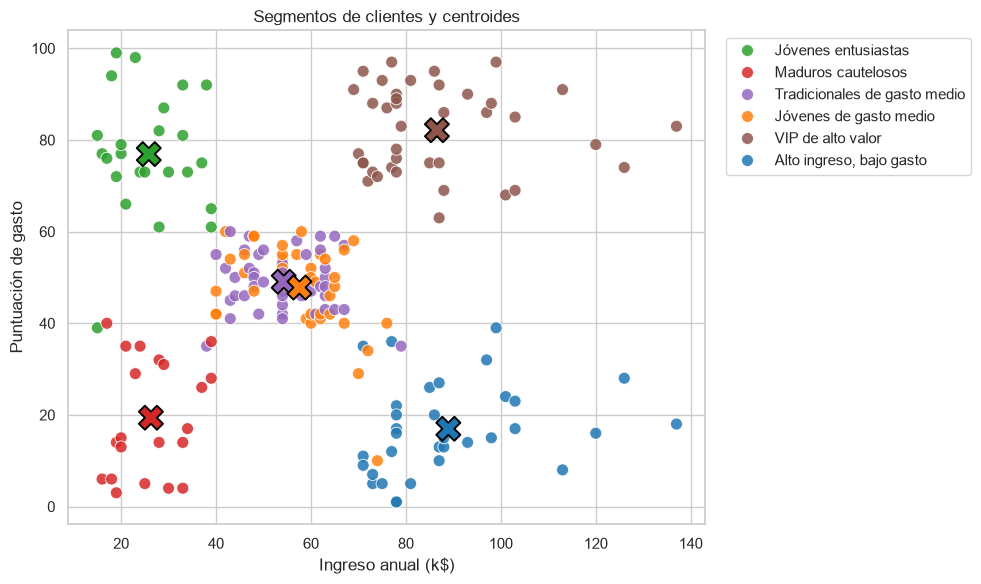

In [7]:
K = 6
model = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=20)
raw_labels = model.fit_predict(scaled_features)

# Nombres estables basados en los centroides, en vez de depender del número arbitrario de K-Means.
raw_centers = pd.DataFrame(scaler.inverse_transform(model.cluster_centers_), columns=feature_columns)

def segment_name(row):
    income, spend, age = row['Annual Income (k$)'], row['Spending Score (1-100)'], row['Age']
    if income >= 70 and spend >= 55: return 'VIP de alto valor'
    if income >= 70 and spend < 55: return 'Alto ingreso, bajo gasto'
    if income < 40 and spend >= 50: return 'Jóvenes entusiastas'
    if income < 40 and spend < 50: return 'Maduros cautelosos'
    if age >= 45: return 'Tradicionales de gasto medio'
    return 'Jóvenes de gasto medio'

name_map = {i: segment_name(row) for i, row in raw_centers.iterrows()}
df['Cluster'] = raw_labels
df['Segment'] = df['Cluster'].map(name_map)
print(f'Silhouette del modelo final: {silhouette_score(scaled_features, raw_labels):.3f}')

palette = dict(zip(sorted(df['Segment'].unique()), sns.color_palette('tab10', K)))
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Segment', palette=palette, s=75, alpha=.85, ax=ax)
centers = raw_centers.copy()
centers['Segment'] = centers.index.map(name_map)
sns.scatterplot(data=centers, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Segment', palette=palette, marker='X', s=300, edgecolor='black',
                legend=False, ax=ax)
ax.set(title='Segmentos de clientes y centroides', xlabel='Ingreso anual (k$)',
       ylabel='Puntuación de gasto')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Perfil de los segmentos

Los centroides son promedios, no clientes “ideales”. El porcentaje femenino se reporta para describir, pero género no participó en el ajuste.

,Clientes,Edad_media,Ingreso_medio_k,Gasto_medio,Porcentaje_mujeres,Porcentaje_clientes
Segment,,,,,,
"Alto ingreso, bajo gasto",33,41.9,88.9,17.0,42.4,16.5
VIP de alto valor,39,32.7,86.5,82.1,53.8,19.5
Jóvenes de gasto medio,38,26.7,57.6,47.8,63.2,19.0
Tradicionales de gasto medio,45,56.3,54.3,49.1,57.8,22.5
Maduros cautelosos,21,45.5,26.3,19.4,61.9,10.5
Jóvenes entusiastas,24,25.2,25.8,76.9,58.3,12.0


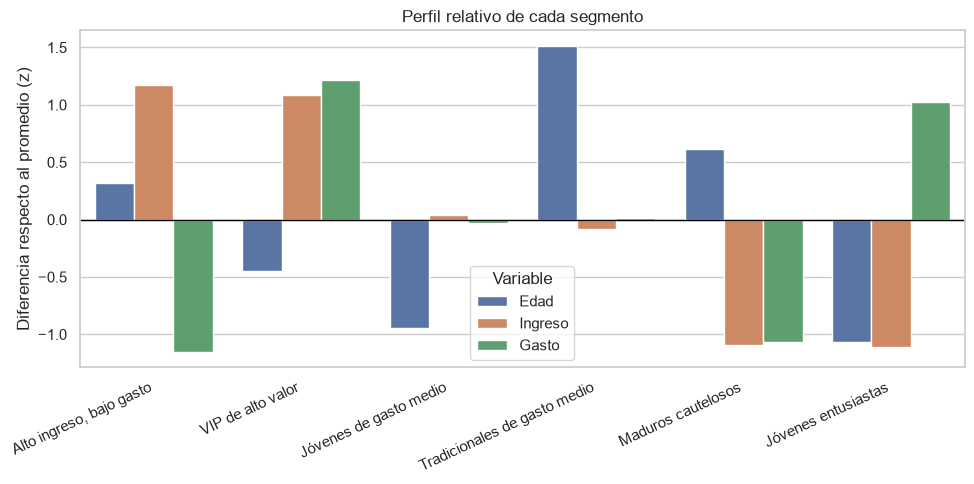

In [8]:
profile = (df.groupby('Segment')
           .agg(Clientes=('CustomerID', 'size'),
                Edad_media=('Age', 'mean'),
                Ingreso_medio_k=('Annual Income (k$)', 'mean'),
                Gasto_medio=('Spending Score (1-100)', 'mean'),
                Porcentaje_mujeres=('Gender', lambda s: s.eq('Female').mean() * 100))
           .assign(Porcentaje_clientes=lambda x: x['Clientes'] / len(df) * 100)
           .sort_values('Ingreso_medio_k', ascending=False))
display(profile.round(1))

long_profile = (profile[['Edad_media', 'Ingreso_medio_k', 'Gasto_medio']]
                .rename(columns={'Edad_media': 'Edad', 'Ingreso_medio_k': 'Ingreso',
                                 'Gasto_medio': 'Gasto'})
                .apply(lambda col: (col - col.mean()) / col.std())
                .reset_index().melt(id_vars='Segment', var_name='Variable', value_name='z'))
plt.figure(figsize=(10, 5))
sns.barplot(data=long_profile, x='Segment', y='z', hue='Variable')
plt.axhline(0, color='black', lw=1)
plt.title('Perfil relativo de cada segmento')
plt.xlabel('')
plt.ylabel('Diferencia respecto al promedio (z)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

## Recomendaciones de marketing

| Segmento | Tamaño | Rasgo distintivo | Acción sugerida |
|---|---:|---|---|
| **VIP de alto valor** | 39 (19.5%) | 32.7 años, 86.5 k$ de ingreso, gasto 82.1 | Programa VIP, acceso anticipado, bundles premium y recompensas por recomendación. Prioridad alta para retención. |
| **Alto ingreso, bajo gasto** | 33 (16.5%) | 41.9 años, mayor ingreso (88.9 k$), gasto 17.0 | Investigar barreras con encuesta/A-B test; ofertas personalizadas y demostraciones de valor, evitando descuentos indiscriminados. |
| **Jóvenes entusiastas** | 24 (12.0%) | 25.2 años, ingreso bajo (25.8 k$), gasto alto (76.9) | Fidelización móvil, promociones asequibles, referidos y productos de entrada. Vigilar fatiga promocional. |
| **Maduros cautelosos** | 21 (10.5%) | 45.5 años, ingreso bajo (26.3 k$), gasto 19.4 | Campañas de valor, descuentos selectivos, productos esenciales y mensajes de ahorro. |
| **Tradicionales de gasto medio** | 45 (22.5%) | 56.3 años, ingreso 54.3 k$, gasto 49.1 | Comunicación simple, servicio/beneficios de confianza y venta cruzada moderada. |
| **Jóvenes de gasto medio** | 38 (19.0%) | 26.7 años, ingreso 57.6 k$, gasto 47.8 | Nutrición digital, recomendaciones personalizadas y pruebas para elevar frecuencia y ticket. |

## Validación, límites y siguiente paso

In [9]:
sample_silhouette = silhouette_samples(scaled_features, raw_labels)
validation = (pd.DataFrame({'Segment': df['Segment'], 'silhouette_individual': sample_silhouette})
              .groupby('Segment')['silhouette_individual']
              .agg(['mean', 'min', 'max']).round(3))
display(validation)

export_columns = ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
                  'Spending Score (1-100)', 'Cluster', 'Segment']
df[export_columns].to_csv('data/retailmax_segmentado.csv', index=False)
print('Archivo generado: data/retailmax_segmentado.csv')

,mean,min,max
Segment,,,
"Alto ingreso, bajo gasto",0.329,-0.019,0.544
Jóvenes de gasto medio,0.393,0.044,0.617
Jóvenes entusiastas,0.488,-0.008,0.653
Maduros cautelosos,0.294,-0.065,0.513
Tradicionales de gasto medio,0.491,0.148,0.644
VIP de alto valor,0.505,0.282,0.640


Archivo generado: data/retailmax_segmentado.csv


### Conclusión

K-Means revela seis perfiles diferenciados y accionables. La principal oportunidad inmediata es retener a los **VIP de alto valor** y convertir, mediante experimentos, al grupo de **alto ingreso y bajo gasto**. Los segmentos no deben tratarse como verdades permanentes: dependen de sólo tres variables, K-Means presupone grupos aproximadamente compactos y la puntuación de gasto es una métrica interna.

Antes de desplegar campañas se recomienda: (1) medir respuesta con pruebas A/B y un grupo de control, (2) añadir datos de recencia, frecuencia, valor monetario, canal y categorías, (3) reentrenar y monitorear tamaños/centroides periódicamente, y (4) evitar decisiones sensibles basadas en género o edad. El éxito debe medirse con conversión, ingreso incremental, margen, retención y bajas de comunicación, no sólo con silhouette.